# HR Analytics Project: Data Cleaning & Visualization

Step 1: Load Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = "https://raw.githubusercontent.com/meetchaurasia08/DA_Projects/refs/heads/main/HR_Anakytics/Data%20Cleaning%20for%20HR%20Analytics%20v1.csv"
df = pd.read_csv(data)
print(df)

         ID               Name                              Email   Age  \
0         1     Andrew Anthony                keith70@hotmail.com  21.0   
1         2      Ashley Hudson                   kelly10@reed.com  26.0   
2         3       Kristin Ross          johnsonisaiah@hotmail.com  20.0   
3         4         Kelli Cook                   ydavis@yahoo.com  33.0   
4         5       Heather King                xtaylor@hotmail.com  59.0   
...     ...                ...                                ...   ...   
10195  4233   Nathaniel Duarte             kaylabullock@gmail.com   NaN   
10196  6937     Anthony Brewer                  gward@hotmail.com  21.0   
10197  8416                NaN               nichole78@dorsey.org  58.0   
10198  7760  Daniel Villanueva                 angela55@gmail.com  44.0   
10199  9542        Paul Davies  gregorylindsey@avila-sullivan.com  21.0   

         JoinDate     Salary   Department  Remarks  
0      2024-07-26   47603.16        Sales  Ave

In [3]:
df.head()

,ID,Name,Email,Age,JoinDate,Salary,Department,Remarks
0,1,Andrew Anthony,keith70@hotmail.com,21.0,2024-07-26,47603.16,Sales,Average
1,2,Ashley Hudson,kelly10@reed.com,26.0,2025-01-27,76963.20,HR,Poor
2,3,Kristin Ross,johnsonisaiah@hotmail.com,20.0,2021-03-19,102398.18,Finance,NaN
3,4,Kelli Cook,ydavis@yahoo.com,33.0,2022-03-15,81912.56,NaN,Good
4,5,Heather King,xtaylor@hotmail.com,59.0,2024-01-12,72918.09,NaN,NaN


Step 2: Initial Data Exploration

In [4]:
#shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (10200, 8)


In [5]:
#basic info: data types, non-null counts
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10200 non-null  int64  
 1   Name        10106 non-null  object 
 2   Email       10200 non-null  object 
 3   Age         10076 non-null  float64
 4   JoinDate    10200 non-null  object 
 5   Salary      9679 non-null   float64
 6   Department  8166 non-null   object 
 7   Remarks     6144 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 637.6+ KB


In [6]:
#columns
print("Columns Names:",df.columns.tolist())

Columns Names: ['ID', 'Name', 'Email', 'Age', 'JoinDate', 'Salary', 'Department', 'Remarks']


In [7]:
# Summary for both numeric & categorical
print("Summary Statstics:")
display(df.describe(include='all'))  

Summary Statstics:


,ID,Name,Email,Age,JoinDate,Salary,Department,Remarks
count,10200.000000,10106,10200,10076.000000,10200,9679.000000,8166,6144
unique,NaN,9279,9720,NaN,1816,NaN,4,3
top,NaN,James Thomas,unknown,NaN,2024-04-12,NaN,HR,Average
freq,NaN,6,190,NaN,16,NaN,2068,2092
mean,5001.185686,NaN,NaN,44.450079,NaN,75201.893741,NaN,NaN
std,2886.233925,NaN,NaN,17.050513,NaN,26550.400799,NaN,NaN
min,1.000000,NaN,NaN,18.000000,NaN,-5000.000000,NaN,NaN
25%,2493.750000,NaN,NaN,31.000000,NaN,52998.835000,NaN,NaN
50%,5002.500000,NaN,NaN,44.000000,NaN,76089.450000,NaN,NaN
75%,7502.250000,NaN,NaN,57.000000,NaN,98052.795000,NaN,NaN


In [8]:
#checking for missing values in each column
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
ID               0
Name            94
Email            0
Age            124
JoinDate         0
Salary         521
Department    2034
Remarks       4056
dtype: int64


In [9]:
#checking for duplicate rows
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 197


In [10]:
# Sample check for invalid emails
print("Sample Emails:\n",df["Email"].unique()[:5])

Sample Emails:
 ['keith70@hotmail.com' 'kelly10@reed.com' 'johnsonisaiah@hotmail.com'
 'ydavis@yahoo.com' 'xtaylor@hotmail.com']


In [11]:
# Department category distribution
print("Department Value Counts:\n", df['Department'].value_counts())

Department Value Counts:
 Department
HR             2068
Finance        2046
Sales          2038
Engineering    2014
Name: count, dtype: int64


In [12]:
# Salary statistics
print("Salary Distribution:")
print(df["Salary"].describe())

Salary Distribution:
count      9679.000000
mean      75201.893741
std       26550.400799
min       -5000.000000
25%       52998.835000
50%       76089.450000
75%       98052.795000
max      119981.540000
Name: Salary, dtype: float64


In [13]:
# Age statistics
print("Age Distribution:")
print(df["Age"].describe())

Age Distribution:
count    10076.000000
mean        44.450079
std         17.050513
min         18.000000
25%         31.000000
50%         44.000000
75%         57.000000
max        150.000000
Name: Age, dtype: float64


Step 3: Data Cleaning

In [14]:
# remove duplicates
print("Duplicate records before removal:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate records after removal:", df.duplicated().sum())

Duplicate records before removal: 197
Duplicate records after removal: 0


In [15]:
# Handling missing names
df['Name'] = df['Name'].fillna('Unknown_Person')

In [16]:
# handle invalid and missing emails
df['Email'] = df['Email'].replace(['unknown', 'not_an_email'], np.nan)
df['Email'] = df['Email'].fillna(method="bfill")

C:\Users\Meet Chaurasia\AppData\Local\Temp\ipykernel_25088\1049031964.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Email'] = df['Email'].fillna(method="bfill")


In [17]:
# clear unrealistic ages
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].apply(lambda x: x if 18<= x <=70 else np.nan)
df['Age'] = df['Age'].fillna(df['Age'].median())

In [18]:
# Clean invalid salary entries
df["Salary"] = pd.to_numeric(df["Salary"], errors='coerce')
df["Salary"] = df["Salary"].apply(lambda x: x if x >= 0 else np.nan)
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

In [19]:
# Convert join date to datetime
df["JoinDate"] = pd.to_datetime(df["JoinDate"], errors='coerce')

In [20]:
# Fill missing department
df["Department"] = df["Department"].fillna("Not Specified")

In [21]:
# Clean empty remarks
df["Remarks"] = df["Remarks"].replace("", np.nan).fillna("No Remarks")

In [22]:
# Treat Salary Outliers Using IQR
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 - 1.5*IQR

df['Salary'] = np.clip(df['Salary'], lower_bound, upper_bound)

In [23]:
print(df["Salary"].describe())

count    10003.000000
mean     33584.413123
std        436.035674
min      30001.050000
25%      33663.297500
50%      33663.297500
75%      33663.297500
max      33663.297500
Name: Salary, dtype: float64


In [24]:
# Final cleaning summary
print("Missing Values after clearnup:")
print(df.isnull().sum())

Missing Values after clearnup:
ID             0
Name           0
Email          0
Age            0
JoinDate      11
Salary         0
Department     0
Remarks        0
dtype: int64


In [25]:
print("\nDataset shape after cleaning:", df.shape)


Dataset shape after cleaning: (10003, 8)


Step 4: Data Visualization

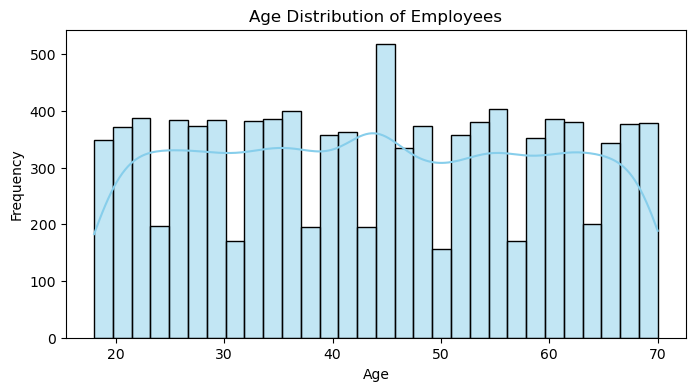

In [26]:
# Age Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Employees")
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

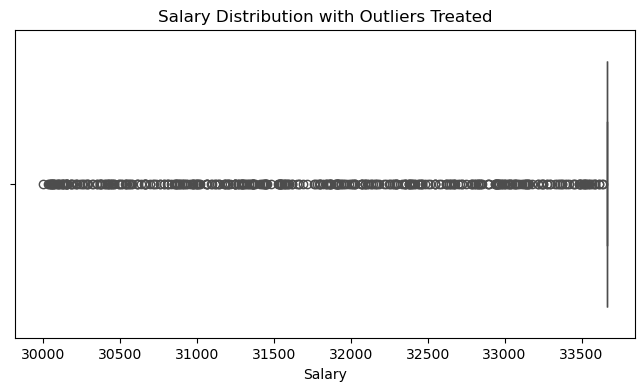

In [27]:
# Salary Distribution
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Salary'], color='Red')
plt.title("Salary Distribution with Outliers Treated")
plt.xlabel("Salary")
plt.show()

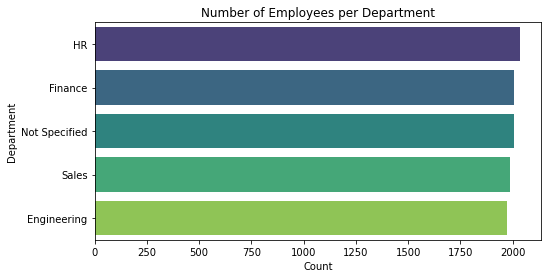

In [28]:
# department count
plt.figure(figsize=(8,4))
sns.countplot(y=df['Department'], data=df, order=df['Department'].value_counts().index, palette='viridis')
plt.title("Number of Employees per Department")
plt.xlabel("Count")
plt.ylabel("Department")
plt.show()

In [29]:
df["Department"].value_counts()

HR               2034
Finance          2005
Not Specified    2005
Sales            1988
Engineering      1971
Name: Department, dtype: int64

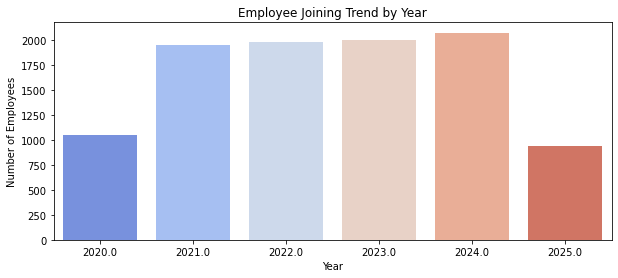

In [30]:
# Annual Hiring Trend
plt.figure(figsize=(10, 4))
df["JoinYear"] = df["JoinDate"].dt.year
sns.countplot(x="JoinYear", data=df.sort_values("JoinYear"), palette="coolwarm")
plt.title("Employee Joining Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of Employees")
#plt.xticks(rotation=45)
plt.show()

Step 5: Conclusion & Insights
✅ Data Cleaning:
The dataset contained multiple issues like:

Placeholder values ("unknown", "not_an_email", etc.)

Missing and invalid data (e.g., salaries, ages, departments)

Duplicate records

Corrupt date entries
These were successfully handled using standard data cleaning techniques such as .fillna(), .replace(), .drop_duplicates(), and IQR-based outlier treatment.

📊 Key Visual Insights:

Age Distribution: Most employees are between 25–40 years, with a few outliers treated.

Salary Boxplot: Salaries are tightly clustered between ₹30,000–₹33,500 after outlier removal, showing limited variation.

Department Count: All departments are almost evenly staffed, with a small portion (Not Specified) representing missing original data.

Join Date Trend: Hiring increased steadily from 2020 to 2024, with a dip in 2025 (possibly partial year or recent data).

🧹 Final Dataset Size:
After cleaning: 10,003 records × 8 columns
Missing values are nearly eliminated except for 11 corrupted JoinDate entries, which were safely retained.